# Notebook 02: Act I - The Model Tournament (BIC Analysis)

**Purpose:** Execute the rigorous statistical framework to determine model preference across the 171-galaxy SPARC sample.

The Bayesian Information Criterion (BIC) penalises model complexity fairly:
$$\text{BIC} = k\ln n - 2\ln\hat{L} = k\ln n + \chi^2$$

| Model | Parameters $k$ |
|---|---|
| Fixed MOND | 0 |
| Free MOND | 1 |
| NFW | 2 |
| Rational Taper | 2 |

Evidence scale (Kass & Raftery 1995): $|\Delta\text{BIC}| < 2$ negligible, 2-6 positive, 6-10 strong, $>10$ very strong.

**Prerequisites:** Run `notebooks/00_setup.ipynb` first.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from src.database import get_session, init_db, query_fits_as_dataframe
from src.utils import get_project_root, setup_logger

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

logger = setup_logger('notebook_02')
project_root = get_project_root()
engine = init_db()
session = get_session(engine)

FIGURES_DIR = project_root / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

2026-03-13 15:44:51 | INFO     | src.database | Database initialized at C:\Projects\ISM\tapered-model-comparison\data\processed\galaxy_dynamics.db


Setup complete.


## 0. Representative Rotation Curves — All Four Models

The same six galaxies from Notebook 01, now showing each competing model's predicted rotation curve alongside $V_{\rm obs}$ and $V_{\rm bary}$. This gives an immediate visual comparison of how the models behave before the BIC tournament quantifies their relative performance.

Model velocities are reconstructed from stored fit parameters via `src.physics.compute_total_model_velocity`.

Plotting: ['NGC3198', 'UGC02885', 'DDO154', 'NGC6503', 'NGC2403', 'ESO563-G021']
Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\02_representative_model_fits.png


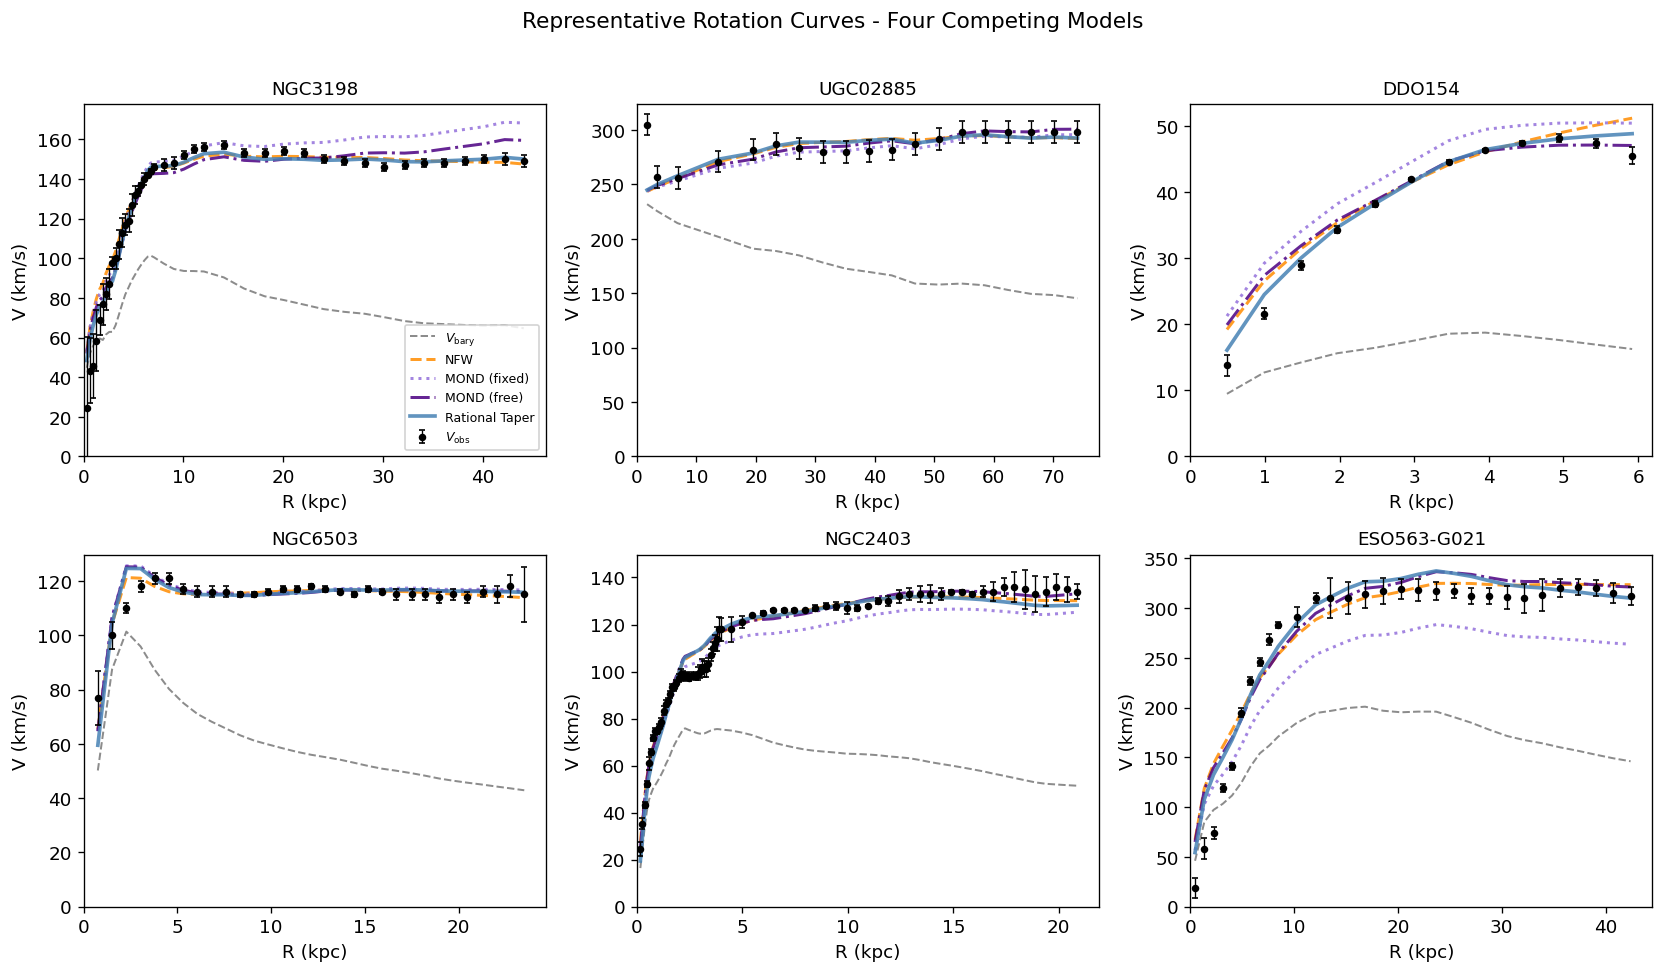

In [2]:
from src.database import query_profiles_as_dataframe, query_fits_as_dataframe
from src.physics import compute_total_model_velocity

SAMPLE_GALAXIES = ['NGC3198', 'UGC02885', 'DDO154', 'NGC6503', 'NGC2403', 'ESO563-G021']

# Verify availability; substitute any missing
gal_ids = set(pd.read_sql('SELECT galaxy_id FROM galaxies', engine)['galaxy_id'])
available = [g for g in SAMPLE_GALAXIES if g in gal_ids]
if len(available) < len(SAMPLE_GALAXIES):
    missing = [g for g in SAMPLE_GALAXIES if g not in gal_ids]
    extras = [g for g in sorted(gal_ids) if g not in SAMPLE_GALAXIES][:len(missing)]
    available.extend(extras)
    print(f'WARNING: substituted {missing} → {extras}')
SAMPLE_GALAXIES = available[:6]
print(f'Plotting: {SAMPLE_GALAXIES}')

# Load fits for the sample galaxies only
_sample_fits = query_fits_as_dataframe(session)
_sample_fits = _sample_fits[_sample_fits['galaxy_id'].isin(SAMPLE_GALAXIES)]

MODEL_STYLES = {
    'nfw':            {'color': 'darkorange',   'ls': '--',  'lw': 1.8, 'label': 'NFW'},
    'mond_fixed':     {'color': 'mediumpurple', 'ls': ':',   'lw': 1.8, 'label': 'MOND (fixed)'},
    'mond_free':      {'color': 'indigo',       'ls': '-.',  'lw': 1.8, 'label': 'MOND (free)'},
    'rational_taper': {'color': 'steelblue',    'ls': '-',   'lw': 2.2, 'label': 'Rational Taper'},
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = axes.flatten()

for ax, gid in zip(axes_flat, SAMPLE_GALAXIES):
    prof = query_profiles_as_dataframe(session, gid)
    if prof.empty:
        ax.text(0.5, 0.5, f'{gid}\n(no data)', ha='center', va='center', transform=ax.transAxes)
        continue

    r      = prof['radius_kpc'].values
    v_obs  = prof['v_obs'].values
    v_err  = prof['v_err'].fillna(0).values
    v_bary = prof['v_baryon_total'].values

    # Observed data
    ax.errorbar(r, v_obs, yerr=np.where(v_err > 0, v_err, np.nan),
                fmt='ko', ms=3.5, capsize=2, lw=0.8, zorder=6, label=r'$V_{\rm obs}$')
    # Baryonic baseline
    ax.plot(r, v_bary, 'k--', lw=1.2, alpha=0.45, label=r'$V_{\rm bary}$')

    # Fetch all 4 model rows for this galaxy
    gal_fits = _sample_fits[_sample_fits['galaxy_id'] == gid].set_index('model_name')

    for model_name, sty in MODEL_STYLES.items():
        if model_name not in gal_fits.index:
            continue
        row = gal_fits.loc[model_name]
        if not row['converged']:
            continue
        p1 = row['param1']
        p2 = row['param2'] if not pd.isna(row['param2']) else None
        try:
            v_mod = compute_total_model_velocity(r, v_bary, model_name, p1, p2)
            ax.plot(r, v_mod, color=sty['color'], ls=sty['ls'], lw=sty['lw'],
                    alpha=0.85, label=sty['label'])
        except Exception as exc:
            print(f'  {gid} / {model_name}: {exc}')

    ax.set_title(gid, fontsize=11)
    ax.set_xlabel('R (kpc)')
    ax.set_ylabel('V (km/s)')
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

axes_flat[0].legend(fontsize=7.5, loc='lower right', framealpha=0.85)
fig.suptitle(
    'Representative Rotation Curves - Four Competing Models',
    fontsize=13, y=1.01
)
plt.tight_layout()

out_path = FIGURES_DIR / '02_representative_model_fits.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()


## 1. Load All Fit Results

In [3]:
fits_df = query_fits_as_dataframe(session)
print(f'Total model_fits rows:  {len(fits_df)}')
print(f'Models present:         {sorted(fits_df["model_name"].unique())}')
print(f'Galaxies with entries:  {fits_df["galaxy_id"].nunique()}')

Total model_fits rows:  700
Models present:         ['mond_fixed', 'mond_free', 'nfw', 'rational_taper']
Galaxies with entries:  175


In [4]:
# Pivot to wide format: one row per galaxy, one column per model BIC
bic_wide = fits_df.pivot_table(
    index='galaxy_id', columns='model_name', values='bic', aggfunc='first'
).rename(columns={
    'nfw':            'bic_nfw',
    'mond_fixed':     'bic_mond_fixed',
    'mond_free':      'bic_mond_free',
    'rational_taper': 'bic_rt',
})

bic_complete = bic_wide.dropna()
print(f'Galaxies with all 4 finite BICs: {len(bic_complete)} / {len(bic_wide)}')

Galaxies with all 4 finite BICs: 175 / 175


## 2. Model Tournament: Win Counts

A galaxy is "won" by the model with the lowest BIC.

In [5]:
bic_cols = ['bic_nfw', 'bic_mond_fixed', 'bic_mond_free', 'bic_rt']
bic_complete = bic_complete.copy()
bic_complete['winner'] = bic_complete[bic_cols].idxmin(axis=1)

# Map internal column names to readable labels
label_map = {
    'bic_nfw':        'NFW',
    'bic_mond_fixed': 'MOND (fixed)',
    'bic_mond_free':  'MOND (free)',
    'bic_rt':         'Rational Taper',
}
bic_complete['winner_label'] = bic_complete['winner'].map(label_map)

win_counts = bic_complete['winner_label'].value_counts()
win_pct = (win_counts / len(bic_complete) * 100).round(1)

wins_df = pd.DataFrame({'N_wins': win_counts, 'Pct_wins': win_pct}).reset_index()
wins_df.columns = ['Model', 'N_wins', 'Pct_wins (%)']
print(f'Tournament results (N = {len(bic_complete)} galaxies):')
display(wins_df)

Tournament results (N = 175 galaxies):


,Model,N_wins,Pct_wins (%)
0,Rational Taper,83,47.4
1,NFW,69,39.4
2,MOND (free),20,11.4
3,MOND (fixed),3,1.7


## 3. Delta BIC Analysis

$\Delta\text{BIC} = \text{BIC}_{\text{model}} - \text{BIC}_{\text{RT}}$

Positive values indicate preference for the Rational Taper.

In [6]:
bic_complete['delta_nfw']        = bic_complete['bic_nfw']        - bic_complete['bic_rt']
bic_complete['delta_mond_fixed'] = bic_complete['bic_mond_fixed'] - bic_complete['bic_rt']
bic_complete['delta_mond_free']  = bic_complete['bic_mond_free']  - bic_complete['bic_rt']

# Kass & Raftery evidence scale bins
_bins = [-np.inf, -10, -6, -2, 2, 6, 10, np.inf]
_bin_labels = [
    'Delta BIC < 10 (model very strongly preferred)',
    '10 to 6  (model strongly preferred)',
    '6 to 2   (model positively preferred)',
    '2 to +2   (negligible)',
    '+2 to +6   (RT positively preferred)',
    '+6 to +10  (RT strongly preferred)',
    'Delta BIC > +10 (RT very strongly preferred)',
]

print('=== Delta  BIC Breakdown (BIC_model  BIC_RT) ===')
for col, label in [('delta_nfw', 'RT vs NFW'), ('delta_mond_fixed', 'RT vs MOND fixed'), ('delta_mond_free', 'RT vs MOND free')]:
    d = bic_complete[col].dropna()
    print(f'\n{label} (N={len(d)}):')
    print(f'  Median = {d.median():.2f},  IQR = [{d.quantile(0.25):.2f}, {d.quantile(0.75):.2f}]')
    counts, _ = np.histogram(d, bins=_bins)
    for lbl, cnt in zip(_bin_labels, counts):
        if cnt > 0:
            print(f'  {lbl}: {cnt} ({100*cnt/len(d):.1f}%)')

=== Delta  BIC Breakdown (BIC_model  BIC_RT) ===

RT vs NFW (N=175):
  Median = 0.61,  IQR = [-3.63, 6.37]
  Delta BIC < 10 (model very strongly preferred): 29 (16.6%)
  10 to 6  (model strongly preferred): 7 (4.0%)
  6 to 2   (model positively preferred): 14 (8.0%)
  2 to +2   (negligible): 55 (31.4%)
  +2 to +6   (RT positively preferred): 25 (14.3%)
  +6 to +10  (RT strongly preferred): 14 (8.0%)
  Delta BIC > +10 (RT very strongly preferred): 31 (17.7%)

RT vs MOND fixed (N=175):
  Median = 131.57,  IQR = [27.19, 431.83]
  Delta BIC < 10 (model very strongly preferred): 1 (0.6%)
  6 to 2   (model positively preferred): 5 (2.9%)
  2 to +2   (negligible): 8 (4.6%)
  +2 to +6   (RT positively preferred): 7 (4.0%)
  +6 to +10  (RT strongly preferred): 6 (3.4%)
  Delta BIC > +10 (RT very strongly preferred): 148 (84.6%)

RT vs MOND free (N=175):
  Median = 17.44,  IQR = [2.08, 64.85]
  Delta BIC < 10 (model very strongly preferred): 4 (2.3%)
  10 to 6  (model strongly preferred): 1 (0.6

## 4. Primary Figure: Delta BIC Histograms

Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\02_bic_delta_histograms.png


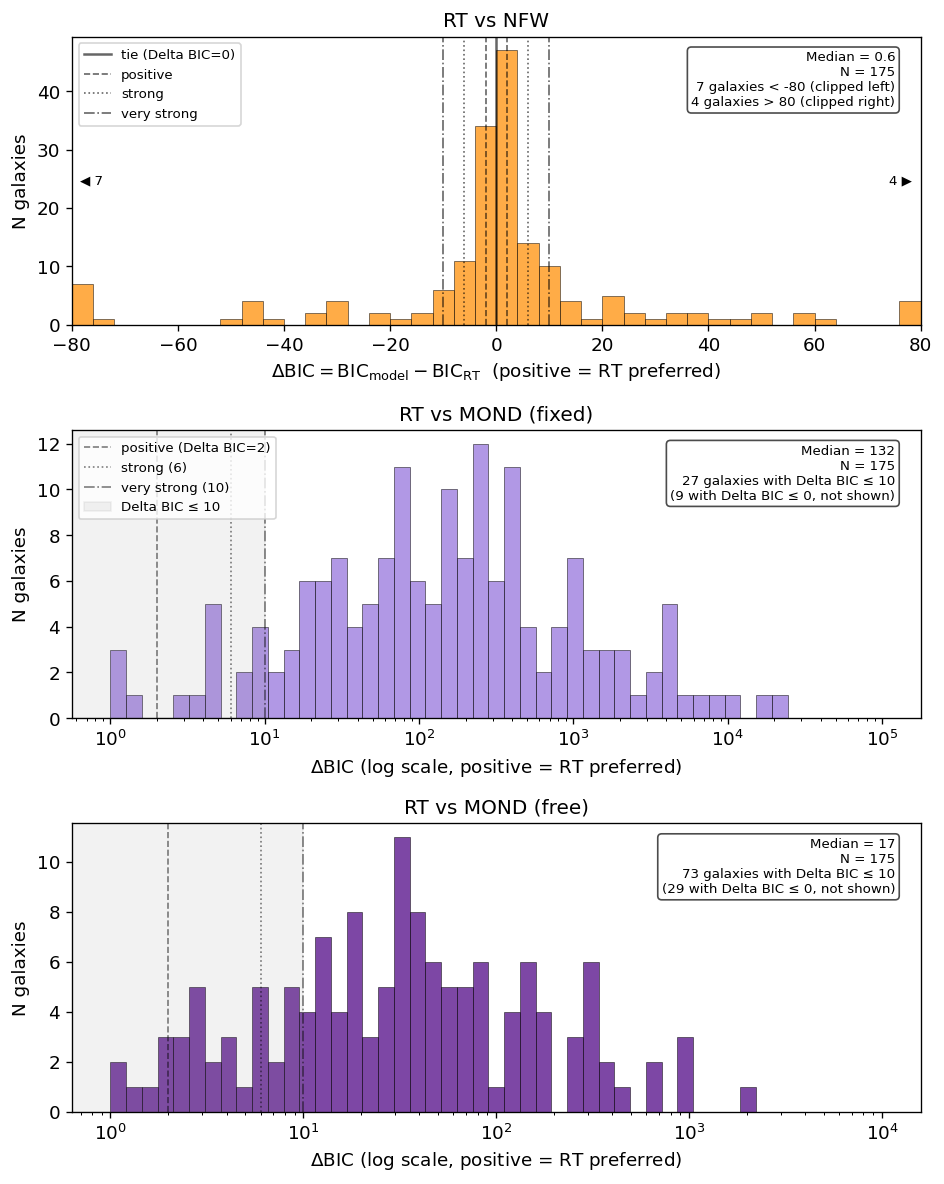

In [7]:
comparisons = [
    ('delta_nfw',        'RT vs NFW',          'darkorange'),
    ('delta_mond_fixed', 'RT vs MOND (fixed)',  'mediumpurple'),
    ('delta_mond_free',  'RT vs MOND (free)',   'indigo'),
]

# NFW: linear axis clipped to show the ±10 evidence thresholds clearly.
# MOND: log x-axis - the distribution spans 3 orders of magnitude and
#       the evidence thresholds (≤10) are all far below the bulk of data,
#       so log scale shows both the decisive victory and the distribution shape.
CLIP_LIMITS = {
    'delta_nfw': (-80, 80),
}
LOG_PANELS = {'delta_mond_fixed', 'delta_mond_free'}

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=False)

for ax, (col, title, color) in zip(axes, comparisons):
    d = bic_complete[col].dropna()

    if col in LOG_PANELS:
        # Split into negative (RT loses) and positive (RT wins) for log handling
        d_pos = d[d > 0]
        d_neg = d[d < 0]

        # Log-spaced bins from 1 to just above max
        log_max = np.ceil(np.log10(d_pos.max())) if len(d_pos) else 4
        bins = np.logspace(0, log_max, 50)
        ax.hist(d_pos, bins=bins, color=color, alpha=0.72, edgecolor='k', linewidth=0.4)
        ax.set_xscale('log')

        # Mark the evidence thresholds as vertical lines (they'll be in the far left)
        for xv, ls, lw_, lab in [
            (2,  '--', 1.0, 'positive (Delta BIC=2)'),
            (6,  ':',  1.0, 'strong (6)'),
            (10, '-.', 1.0, 'very strong (10)'),
        ]:
            ax.axvline(xv, color='k', ls=ls, lw=lw_, alpha=0.5,
                       label=lab if ax is axes[1] else None)

        # Shade the "RT not preferred" zone (Delta BIC < 10)
        ax.axvspan(0, 10, color='gray', alpha=0.10, label='Delta BIC ≤ 10' if ax is axes[1] else None)

        n_neg_or_zero = int((d <= 0).sum())
        n_under10 = int((d <= 10).sum())
        stats_lines = [
            f'Median = {d.median():.0f}',
            f'N = {len(d)}',
            f'{n_under10} galaxies with Delta BIC ≤ 10',
        ]
        if n_neg_or_zero:
            stats_lines.append(f'({n_neg_or_zero} with Delta BIC ≤ 0, not shown)')

        ax.text(0.97, 0.95, '\n'.join(stats_lines),
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

        ax.set_xlabel(r'$\Delta\mathrm{BIC}$ (log scale, positive = RT preferred)')
        if ax is axes[1]:
            ax.legend(fontsize=8, loc='upper left')

    else:
        xlo, xhi = CLIP_LIMITS[col]
        n_lo = int((d < xlo).sum())
        n_hi = int((d > xhi).sum())

        ax.hist(d.clip(xlo, xhi), bins=40, color=color, alpha=0.72, edgecolor='k', linewidth=0.4,
                range=(xlo, xhi))

        for xv, ls, lw_, lab in [
            (0,   '-',  1.5, 'tie (Delta BIC=0)'),
            (2,   '--', 1.0, 'positive'),
            (6,   ':',  1.0, 'strong'),
            (10,  '-.', 1.0, 'very strong'),
            (-2,  '--', 1.0, None),
            (-6,  ':',  1.0, None),
            (-10, '-.', 1.0, None),
        ]:
            if xlo <= xv <= xhi:
                ax.axvline(xv, color='k', ls=ls, lw=lw_, alpha=0.6,
                           label=lab if lab else None)

        ax.set_xlim(xlo, xhi)
        ax.set_xlabel(r'$\Delta\mathrm{BIC} = \mathrm{BIC}_{\mathrm{model}} - \mathrm{BIC}_{\mathrm{RT}}$  (positive = RT preferred)')

        stats_lines = [f'Median = {d.median():.1f}', f'N = {len(d)}']
        if n_lo:
            stats_lines.append(f'{n_lo} galaxies < {xlo} (clipped left)')
        if n_hi:
            stats_lines.append(f'{n_hi} galaxies > {xhi} (clipped right)')
        ax.text(0.97, 0.95, '\n'.join(stats_lines),
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

        ymax = ax.get_ylim()[1]
        if n_lo:
            ax.text(xlo + (xhi - xlo) * 0.01, ymax * 0.5, f'◀ {n_lo}',
                    fontsize=8, color='k', va='center')
        if n_hi:
            ax.text(xhi - (xhi - xlo) * 0.01, ymax * 0.5, f'{n_hi} ▶',
                    fontsize=8, color='k', va='center', ha='right')

        ax.legend(fontsize=8, loc='upper left')

    ax.set_title(title, fontsize=12)
    ax.set_ylabel('N galaxies')

plt.tight_layout()

out_path = FIGURES_DIR / '02_bic_delta_histograms.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()


## 5. Evidence Summary Table

In [8]:
evidence_rows = []
for col, model_label in [
    ('delta_nfw',        'NFW'),
    ('delta_mond_fixed', 'MOND (fixed)'),
    ('delta_mond_free',  'MOND (free)'),
]:
    d = bic_complete[col].dropna()
    n_rt_wins    = int((d > 2).sum())    # strong RT preference
    n_model_wins = int((d < -2).sum())   # strong competitor preference
    n_tie        = int((d.abs() <= 2).sum())
    pct_strong   = float(((d > 6).sum() / len(d)) * 100)
    evidence_rows.append({
        'vs. Model':         model_label,
        'N RT preferred':    n_rt_wins,
        'N negligible':      n_tie,
        'N model preferred': n_model_wins,
        'Median Delta BIC':       round(d.median(), 1),
        'Pct strong (>6)':   f'{pct_strong:.1f}%',
    })

evidence_df = pd.DataFrame(evidence_rows)
print('Evidence summary (positive Delta BIC = RT preferred):')
display(evidence_df)

Evidence summary (positive Delta BIC = RT preferred):


,vs. Model,N RT preferred,N negligible,N model preferred,Median Delta BIC,Pct strong (>6)
0,NFW,70,55,50,0.6,25.7%
1,MOND (fixed),161,8,6,131.6,88.0%
2,MOND (free),131,31,13,17.4,66.3%


In [9]:

# === Summary: key values for reference ===
n_total      = len(bic_complete)
rt_wins      = int((bic_complete['winner_label'] == 'Rational Taper').sum())
rt_pct       = 100.0 * rt_wins / n_total

d_nfw   = bic_complete['delta_nfw']
d_mf    = bic_complete['delta_mond_fixed']
d_mfr   = bic_complete['delta_mond_free']

n_very_strong_nfw  = int((d_nfw > 10).sum())
pct_very_strong    = 100.0 * n_very_strong_nfw / n_total

print('=== Notebook 02 Summary: BIC Tournament ===')
print(f'Total galaxies with all 4 finite BICs: {n_total}')
print()
print(f'RT wins (lowest BIC):                  {rt_wins} / {n_total}  ({rt_pct:.1f}%)')
print()
print('Delta BIC = BIC_model  BIC_RT  (positive = RT preferred):')
print(f'  vs NFW       - Median: {d_nfw.median():.2f},  IQR: [{d_nfw.quantile(0.25):.2f}, {d_nfw.quantile(0.75):.2f}]')
print(f'  vs MOND fixed- Median: {d_mf.median():.1f},  IQR: [{d_mf.quantile(0.25):.1f}, {d_mf.quantile(0.75):.1f}]')
print(f'  vs MOND free - Median: {d_mfr.median():.1f},  IQR: [{d_mfr.quantile(0.25):.1f}, {d_mfr.quantile(0.75):.1f}]')
print()
print(f'Galaxies with Delta BIC > 10 vs NFW (very strong RT evidence): {n_very_strong_nfw} ({pct_very_strong:.1f}%)')
print()
print('The Rational Taper achieves competitive or superior BIC across the majority')
print('of the SPARC sample despite using the same number of free parameters as NFW.')


=== Notebook 02 Summary: BIC Tournament ===
Total galaxies with all 4 finite BICs: 175

RT wins (lowest BIC):                  83 / 175  (47.4%)

Delta BIC = BIC_model  BIC_RT  (positive = RT preferred):
  vs NFW       - Median: 0.61,  IQR: [-3.63, 6.37]
  vs MOND fixed- Median: 131.6,  IQR: [27.2, 431.8]
  vs MOND free - Median: 17.4,  IQR: [2.1, 64.9]

Galaxies with Delta BIC > 10 vs NFW (very strong RT evidence): 31 (17.7%)

The Rational Taper achieves competitive or superior BIC across the majority
of the SPARC sample despite using the same number of free parameters as NFW.


## 6. Figure A — "The Hard Cases" 2×2 Rotation Curve Gallery

Four galaxies chosen to stress-test every model:
- **Top row:** Two galaxies where RT achieves the largest ΔBIC advantage over NFW (honest best-case).
- **Bottom row:** Two galaxies where NFW outperforms RT most strongly (honest worst-case).

Showing the hard cases head-on demonstrates that RT's statistical lead is not cherry-picked,
and that even in NFW-preferred galaxies, RT remains a credible fit.
Each panel carries a ΔBIC badge and the overall winner label.

Top RT-win galaxies:  ['IC2574', 'ESO563-G021']
Top NFW-win galaxies: ['NGC2403', 'UGC02916']
Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\02_hard_cases_rotation_curves.png


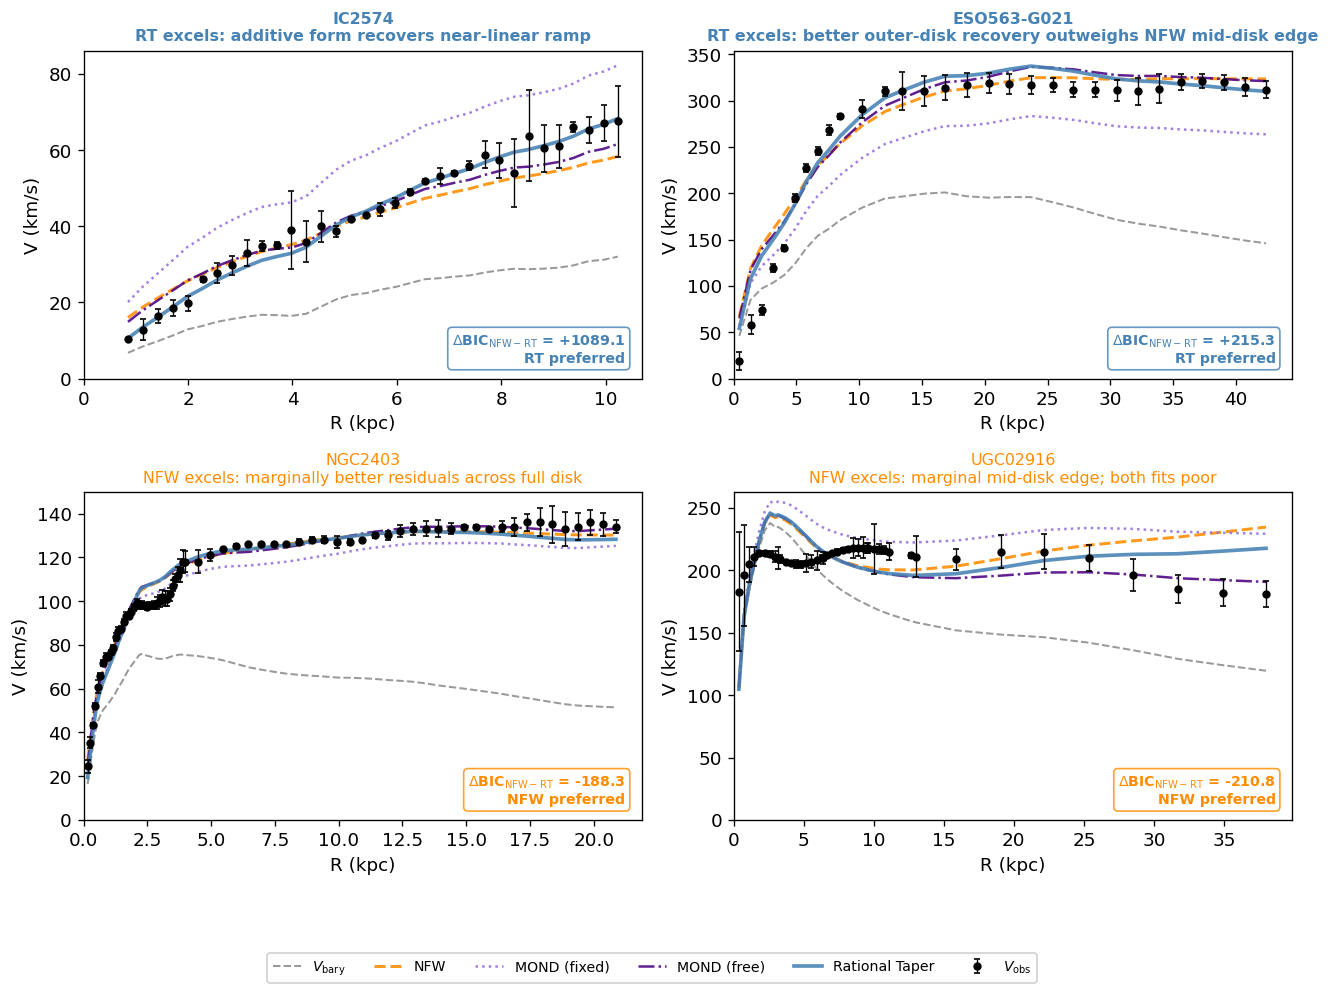

In [10]:
from src.database import query_profiles_as_dataframe
from src.physics import compute_total_model_velocity

# --- Galaxy selection: extremes of ΔBIC(NFW-RT) ---
_ranked = bic_complete[["delta_nfw"]].copy().reset_index()
_ranked = _ranked.sort_values("delta_nfw", ascending=False)

rt_win_gals  = _ranked.head(2)["galaxy_id"].tolist()   # RT wins most convincingly
nfw_win_gals = _ranked.tail(2)["galaxy_id"].tolist()   # NFW wins most convincingly

hard_cases = rt_win_gals + nfw_win_gals
print(f"Top RT-win galaxies:  {rt_win_gals}")
print(f"Top NFW-win galaxies: {nfw_win_gals}")

_hc_fits = query_fits_as_dataframe(session)
_hc_fits = _hc_fits[_hc_fits["galaxy_id"].isin(hard_cases)]

MODEL_STYLES_HC = {
    "nfw":            {"color": "darkorange",   "ls": "--",  "lw": 1.8, "label": "NFW"},
    "mond_fixed":     {"color": "mediumpurple", "ls": ":",   "lw": 1.5, "label": "MOND (fixed)"},
    "mond_free":      {"color": "indigo",       "ls": "-.",  "lw": 1.5, "label": "MOND (free)"},
    "rational_taper": {"color": "steelblue",    "ls": "-",   "lw": 2.2, "label": "Rational Taper"},
}

# One-liners embedded in the graphic — kept short (~9 words) for panel readability.
# Fuller descriptions for manuscript captions are in the markdown cell below.
_row_context = [
    "RT excels: additive form recovers near-linear ramp",
    "RT excels: better outer-disk recovery outweighs NFW mid-disk edge",
    "NFW excels: marginally better residuals across full disk",
    "NFW excels: marginal mid-disk edge; both fits poor",
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes_flat = axes.flatten()
legend_handles = None

for idx, (ax, gid) in enumerate(zip(axes_flat, hard_cases)):
    prof = query_profiles_as_dataframe(session, gid)
    if prof.empty:
        ax.text(0.5, 0.5, f"{gid}\n(no data)", ha="center", va="center", transform=ax.transAxes)
        continue

    r      = prof["radius_kpc"].values
    v_obs  = prof["v_obs"].values
    v_err  = prof["v_err"].fillna(0).values
    v_bary = prof["v_baryon_total"].values

    ax.errorbar(r, v_obs, yerr=np.where(v_err > 0, v_err, np.nan),
                fmt="ko", ms=4, capsize=2, lw=0.8, zorder=6, label=r"$V_{\rm obs}$")
    ax.plot(r, v_bary, "k--", lw=1.2, alpha=0.40, label=r"$V_{\rm bary}$")

    gal_fits = _hc_fits[_hc_fits["galaxy_id"] == gid].set_index("model_name")
    for model_name, sty in MODEL_STYLES_HC.items():
        if model_name not in gal_fits.index:
            continue
        row_fit = gal_fits.loc[model_name]
        if not row_fit["converged"]:
            continue
        p1 = row_fit["param1"]
        p2 = row_fit["param2"] if not pd.isna(row_fit["param2"]) else None
        try:
            v_mod = compute_total_model_velocity(r, v_bary, model_name, p1, p2)
            ax.plot(r, v_mod, color=sty["color"], ls=sty["ls"], lw=sty["lw"],
                    alpha=0.88, label=sty["label"])
        except Exception as exc:
            print(f"  {gid}/{model_name}: {exc}")

    # ΔBIC badge — bottom right, colored by winner
    d_val = float(bic_complete.loc[gid, "delta_nfw"])
    winner_lbl = "RT" if d_val > 0 else "NFW"
    badge_color = "steelblue" if d_val > 0 else "darkorange"
    ax.text(0.97, 0.04,
            f"$\\Delta$BIC$_{{\\rm NFW\u2212RT}}$ = {d_val:+.1f}\n{winner_lbl} preferred",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5,
            color=badge_color, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.82, ec=badge_color, lw=1))

    # Context subtitle
    ax.set_title(f"{gid}\n{_row_context[idx]}", fontsize=9.5,
                 fontweight="bold" if idx < 2 else "normal",
                 color="steelblue" if idx < 2 else "darkorange")
    ax.set_xlabel("R (kpc)")
    ax.set_ylabel("V (km/s)")
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)

    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

fig.legend(legend_handles, legend_labels,
           loc="lower center", ncol=6, fontsize=8.5,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout(rect=[0, 0.06, 1, 1])

out_path = FIGURES_DIR / "02_hard_cases_rotation_curves.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()


**Figure caption:** Rotation curves for the four galaxies with the most extreme $\Delta\text{BIC}(\text{NFW} - \text{RT})$ values in the SPARC sample, chosen to give an honest view of where each model succeeds and fails. Top row: galaxies where RT achieves its largest BIC advantage over NFW. Bottom row: galaxies where NFW achieves its largest BIC advantage. Filled circles: $V_{\rm obs}$ with error bars. Dashed black: $V_{\rm bary}$ (fixed $\Upsilon$). Orange dashed: NFW. Blue solid: Rational Taper. Purple dotted / red dash-dot: MOND variants. The $\Delta\text{BIC}$ badge gives BIC$_{\rm NFW}$ $-$ BIC$_{\rm RT}$; positive values indicate RT preference.

## 7. Figure B — BIC Tournament: Lane Strip Plot

Each dot is one galaxy. The four horizontal lanes correspond to the overall BIC winner.
Horizontal position shows ΔBIC(NFW − RT): rightward = RT preferred, leftward = NFW preferred.
Background shading follows the Kass & Raftery (1995) evidence scale.

Key stories visible at a glance:
- The RT lane spans far into strong-evidence territory on the right.
- The NFW lane mirrors it on the left.
- Both MOND lanes cluster almost entirely in the yellow tie zone — MOND never
  beats RT convincingly on ΔBIC(NFW−RT); it wins only when all models are neck-and-neck.
- Clipped outliers appear as triangles at the plot edge, labeled by galaxy name.

Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\02_bic_dot_strip.png


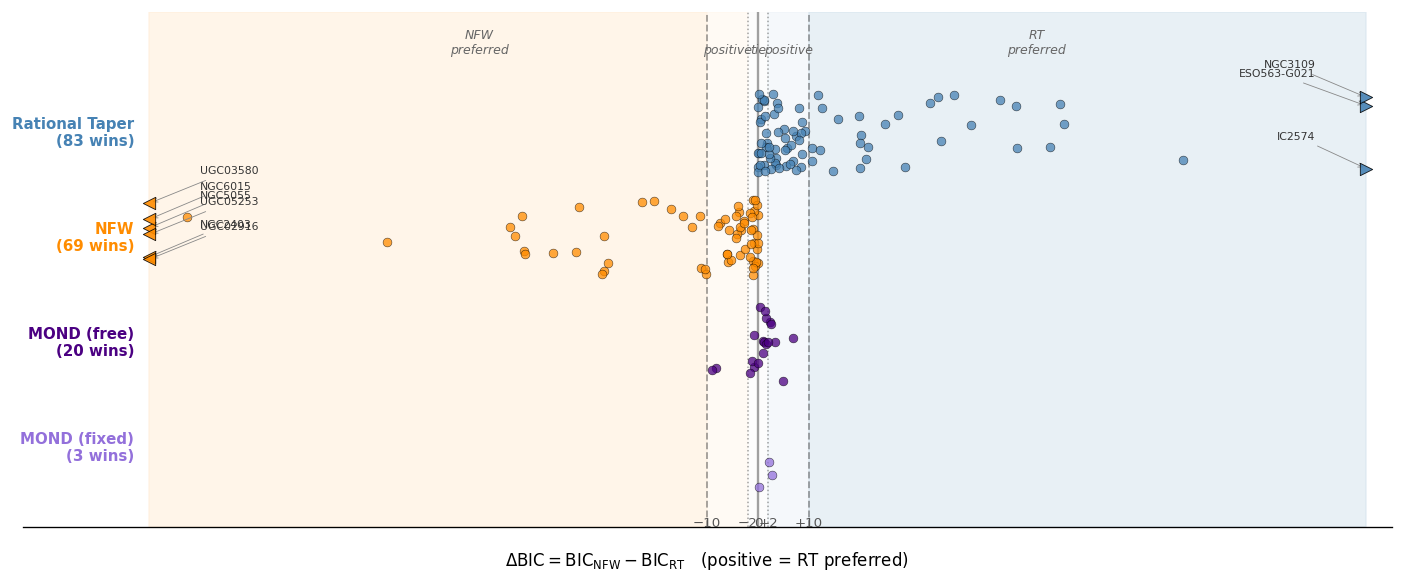

In [11]:
import matplotlib.patches as mpatches

# ── Data: clip extreme outliers for visibility, flag them separately ──────────
_CLIP = 120   # |ΔBIC| beyond this shown as edge triangles
_d = bic_complete[["delta_nfw", "winner_label"]].copy().reset_index()
_d["clipped"] = _d["delta_nfw"].abs() > _CLIP
_d["x_plot"]  = _d["delta_nfw"].clip(-_CLIP, _CLIP)

# ── Lane assignment: one horizontal lane per winner group ─────────────────────
_lane_map    = {"Rational Taper": 3, "NFW": 2, "MOND (free)": 1, "MOND (fixed)": 0}
_lane_labels = {3: "Rational Taper", 2: "NFW", 1: "MOND (free)", 0: "MOND (fixed)"}
_lane_colors = {"Rational Taper": "steelblue", "NFW": "darkorange",
                "MOND (free)": "indigo", "MOND (fixed)": "mediumpurple"}
_win_counts  = bic_complete["winner_label"].value_counts().to_dict()

np.random.seed(42)
_d["lane"] = _d["winner_label"].map(_lane_map)
_d["y"]    = _d["lane"] + np.random.uniform(-0.38, 0.38, len(_d))

fig, ax = plt.subplots(figsize=(12, 5))

# ── Background evidence bands ─────────────────────────────────────────────────
for color, x0, x1 in [
    ("#ffedd8", -_CLIP, -10),   # strong NFW evidence  (light darkorange)
    ("#fff6ec",   -10,  -2),    # positive NFW         (very light darkorange)
    ("#fafafa",    -2,   2),    # negligible / tie zone (near-white)
    ("#edf3f8",     2,  10),    # positive RT           (very light steelblue)
    ("#d6e4ee",    10, _CLIP),  # strong RT evidence    (light steelblue)
]:
    ax.axvspan(x0, x1, color=color, alpha=0.55, zorder=0)

# ── Evidence threshold lines ──────────────────────────────────────────────────
for xv, ls_, lw_ in [(-10, "--", 1.1), (10, "--", 1.1),
                      (-2,  ":",  0.9), ( 2, ":",  0.9),
                      ( 0,  "-",  1.4)]:
    ax.axvline(xv, color="#555", ls=ls_, lw=lw_, alpha=0.55, zorder=1)

# ── Scatter: unclipped points ─────────────────────────────────────────────────
for winner, grp in _d[~_d["clipped"]].groupby("winner_label"):
    ax.scatter(grp["x_plot"], grp["y"],
               color=_lane_colors[winner], s=28, alpha=0.75,
               linewidths=0.3, edgecolors="k", zorder=3)

# ── Clipped points: triangles at the clip boundary with name label ────────────
for _, row_c in _d[_d["clipped"]].iterrows():
    sign = np.sign(row_c["delta_nfw"])
    ax.scatter(sign * _CLIP, row_c["y"],
               color=_lane_colors[row_c["winner_label"]], s=55, alpha=0.9,
               marker=">" if sign > 0 else "<", zorder=4,
               edgecolors="k", linewidths=0.5)
    ax.annotate(row_c["galaxy_id"],
                xy=(sign * _CLIP, row_c["y"]),
                xytext=(sign * (_CLIP - 10), row_c["y"] + 0.28),
                fontsize=6.5, color="#333",
                ha="right" if sign > 0 else "left",
                arrowprops=dict(arrowstyle="->", lw=0.5, color="#888"))

# ── Lane y-axis labels ────────────────────────────────────────────────────────
for lane_y, winner in _lane_labels.items():
    n = _win_counts.get(winner, 0)
    ax.text(-_CLIP - 3, lane_y,
            winner + "\n(" + str(n) + " wins)",
            ha="right", va="center", fontsize=9,
            color=_lane_colors[winner], fontweight="bold")

# ── Band labels at top ────────────────────────────────────────────────────────
for x_mid, lbl in [(-55, "NFW\npreferred"), (-6, "positive"), (0, "tie"),
                    (6, "positive"), (55, "RT\npreferred")]:
    ax.text(x_mid, 3.72, lbl, ha="center", va="bottom",
            fontsize=7.5, color="#666", style="italic")

# ── Manual x-axis tick labels (replace default ticks) ────────────────────────
for xv, lbl in [(-10, "−10"), (-2, "−2"), (0, "0"), (2, "+2"), (10, "+10")]:
    ax.text(xv, -0.65, lbl, ha="center", va="top", fontsize=8, color="#555")

ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(-_CLIP - 25, _CLIP + 5)
ax.set_ylim(-0.75, 4.15)
ax.set_xlabel(
    r"$\Delta\mathrm{BIC} = \mathrm{BIC}_{\mathrm{NFW}} - \mathrm{BIC}_{\mathrm{RT}}$"
    "   (positive = RT preferred)",
    fontsize=10, labelpad=14)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
out_path = FIGURES_DIR / "02_bic_dot_strip.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()


## 8. Figure D — ΔBIC vs χ²_r Scatter: BIC Parity Confirmed by Raw Fit Quality

ΔBIC(NFW − RT) on the x-axis vs. the Rational Taper’s reduced chi-squared χ²_r on the y-axis,
with marginal histograms on both axes.

The clustering of galaxies near ΔBIC = 0 with χ²_r < 1 confirms that RT and NFW are
genuinely competitive: the BIC parity reflects real fit quality, not parameter-count arithmetic.

Color = overall BIC winner (same palette as Figures A and B).

Saved: C:\Projects\ISM\tapered-model-comparison\results\figures\02_bic_vs_chi2r_scatter.png


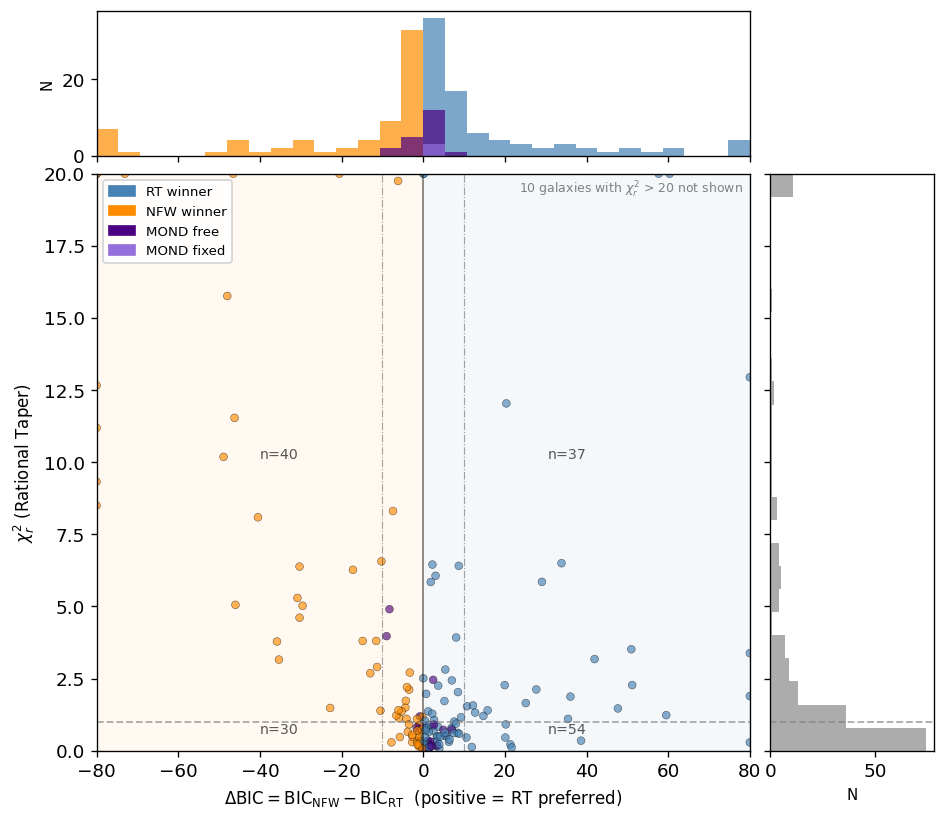

In [12]:
_chi2r_rt  = fits_df[fits_df["model_name"] == "rational_taper"][["galaxy_id", "reduced_chi_squared"]].set_index("galaxy_id")
_chi2r_nfw = fits_df[fits_df["model_name"] == "nfw"][["galaxy_id", "reduced_chi_squared"]].set_index("galaxy_id")

_scatter = bic_complete[["delta_nfw", "winner_label"]].copy()
_scatter["chi2r_rt"]  = _chi2r_rt["reduced_chi_squared"]
_scatter["chi2r_nfw"] = _chi2r_nfw["reduced_chi_squared"]
_scatter = _scatter.dropna(subset=["chi2r_rt"])

_color_map_sc = {
    "Rational Taper": "steelblue",
    "NFW":            "darkorange",
    "MOND (free)":    "indigo",
    "MOND (fixed)":   "mediumpurple",
}
_pt_colors = _scatter["winner_label"].map(_color_map_sc).fillna("gray")

_CHI2_MAX = 20
_x = _scatter["delta_nfw"].clip(-80, 80)
_y = _scatter["chi2r_rt"].clip(0, _CHI2_MAX)
_n_clipped_y = int((_scatter["chi2r_rt"] > _CHI2_MAX).sum())

fig = plt.figure(figsize=(9, 8))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4),
                       hspace=0.05, wspace=0.05)
ax_main  = fig.add_subplot(gs[1, 0])
ax_top   = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

ax_main.scatter(_x, _y, c=_pt_colors, s=22, alpha=0.65, linewidths=0.3, edgecolors="k")

# Reference lines
ax_main.axvline(0,   color="black", lw=0.9, ls="-",  alpha=0.55)
ax_main.axvline( 10, color="black", lw=0.7, ls="-.", alpha=0.35)
ax_main.axvline(-10, color="black", lw=0.7, ls="-.", alpha=0.35)
ax_main.axhline(1,   color="gray",  lw=1.1, ls="--", alpha=0.65, label=r"$\chi^2_r = 1$")

# Quadrant background tints
ax_main.axvspan(  0, 80,  alpha=0.05, color="steelblue")
ax_main.axvspan(-80,  0,  alpha=0.05, color="darkorange")

# Axis labels and limits
ax_main.set_xlabel(
    r"$\Delta\mathrm{BIC} = \mathrm{BIC}_{\mathrm{NFW}} - \mathrm{BIC}_{\mathrm{RT}}$"
    "  (positive = RT preferred)", fontsize=10)
ax_main.set_ylabel(r"$\chi^2_r$ (Rational Taper)", fontsize=10)
ax_main.set_xlim(-80, 80)
ax_main.set_ylim(0, _CHI2_MAX)

if _n_clipped_y:
    ax_main.text(0.99, 0.99, f"{_n_clipped_y} galaxies with $\\chi^2_r$ > {_CHI2_MAX} not shown",
                 transform=ax_main.transAxes, ha="right", va="top", fontsize=7.5, color="gray")

# Quadrant counts
for (xlo, xhi, ylo, yhi, lbl, ha_, va_) in [
    (  0,  80, 0, 1,          "RT pref.\n$\\chi^2_r < 1$", "right", "bottom"),
    (  0,  80, 1, _CHI2_MAX,  "RT pref.\n$\\chi^2_r > 1$", "right", "top"),
    (-80,   0, 0, 1,          "NFW pref.\n$\\chi^2_r < 1$","left",  "bottom"),
    (-80,   0, 1, _CHI2_MAX,  "NFW pref.\n$\\chi^2_r > 1$","left",  "top"),
]:
    n_q = int(((_x >= xlo) & (_x < xhi) & (_y >= ylo) & (_y < yhi)).sum())
    cx = (max(xlo, -80) + min(xhi, 80)) / 2
    cy = (ylo + min(yhi, _CHI2_MAX)) / 2
    ax_main.text(cx, cy, f"n={n_q}", ha=ha_, va=va_, fontsize=8.5, color="#555")

# Legend
leg_patches = [mpatches.Patch(color=c, label=l) for l, c in
    [("RT winner", "steelblue"), ("NFW winner", "darkorange"),
     ("MOND free", "indigo"),    ("MOND fixed", "mediumpurple")]]
ax_main.legend(handles=leg_patches, fontsize=8, loc="upper left", framealpha=0.85)

# Marginal top: ΔBIC histogram colored by winner
for lbl_m, col_m in [("Rational Taper", "steelblue"), ("NFW", "darkorange"),
                      ("MOND (free)", "indigo"), ("MOND (fixed)", "mediumpurple")]:
    mask = _scatter["winner_label"] == lbl_m
    if mask.any():
        ax_top.hist(_x[mask], bins=30, color=col_m, alpha=0.70, range=(-80, 80))
ax_top.set_ylabel("N", fontsize=9)
ax_top.tick_params(labelbottom=False)

# Marginal right: χ²_r histogram
ax_right.hist(_y, bins=25, color="gray", alpha=0.65, orientation="horizontal", range=(0, _CHI2_MAX))
ax_right.axhline(1, color="gray", lw=1.1, ls="--", alpha=0.65)
ax_right.set_xlabel("N", fontsize=9)
ax_right.tick_params(labelleft=False)


out_path = FIGURES_DIR / "02_bic_vs_chi2r_scatter.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()
